In [1]:
# Código para entrenamiento de CNN
# ============================================================
# 1. CONEXIÓN A GOOGLE DRIVE E IMPORTACIÓN DE LIBRERÍAS
# ============================================================

"""
En esta sección se conecta Google Drive para acceder al dataset
almacenado en la carpeta del proyecto. Además, se importan las
librerías necesarias para:

- cargar imágenes,
- construir datasets de TensorFlow,
- entrenar el modelo,
- calcular métricas,
- visualizar resultados.
"""

from google.colab import drive
drive.mount('/content/drive')

import time
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# DenseNet 121 - Modelo de transfer learning elegido
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras import layers, models

Mounted at /content/drive


In [2]:
# ============================================================
# 2. DEFINICIÓN DE RUTA Y PARÁMETROS GENERALES
# ============================================================

"""
Para este avance se trabajará únicamente con la carpeta train,
debido a que contiene la mayor cantidad de imágenes disponibles, posee
1341 imágenes para clase NORMAL y 3875 imágenes para PNEUMONÍA

A partir de esta carpeta se realizará una nueva división interna:
- entrenamiento
- validación

La división será estratificada para conservar la proporción entre
las clases NORMAL y PNEUMONIA.
"""

BASE = Path('/content/drive/MyDrive/proyecto_patrones_MIV/XRAY')

TRAIN_ORIGINAL_DIR = BASE / 'train'

IMG_SIZE = (224, 224) # Redimensionamiento de 224 x 224
BATCH_SIZE = 32 # Batch predeterminado
SEED = 42 # Semilla que controla la aleatoriedad

print("Ruta train existe:", TRAIN_ORIGINAL_DIR.exists())

# Para ver si existe GPU
tf.config.list_physical_devices('GPU')

Ruta train existe: True


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [3]:
# ============================================================
# 3. VERIFICACIÓN DE IMÁGENES EN TRAIN
# ============================================================

"""
Se verifica la cantidad de imágenes disponibles en la carpeta train
para cada clase. Esta información permite identificar el tamaño real
del conjunto de trabajo y evaluar si existe desbalance entre clases.
"""

CLASES = ['NORMAL', 'PNEUMONIA']

image_paths = []
labels = []

for idx, clase in enumerate(CLASES):
    carpeta = TRAIN_ORIGINAL_DIR / clase
    archivos = list(carpeta.glob('*'))

    print(f"{clase}: {len(archivos)} imágenes")

    for archivo in archivos:
        image_paths.append(str(archivo))
        labels.append(idx)

image_paths = np.array(image_paths)
labels = np.array(labels)

print("\nTotal de imágenes usadas:", len(image_paths))
print("0 = NORMAL")
print("1 = PNEUMONIA")
print("Ruta = image_paths shape:", image_paths.shape)
print("Etiquetas = labels shape:", labels.shape)

NORMAL: 1341 imágenes
PNEUMONIA: 3875 imágenes

Total de imágenes usadas: 5216
0 = NORMAL
1 = PNEUMONIA
Ruta = image_paths shape: (5216,)
Etiquetas = labels shape: (5216,)


In [4]:
# ============================================================
# 4. DIVISIÓN ESTRATIFICADA TRAIN / VALIDATION
# ============================================================

"""
A partir de la carpeta train original se crea una división interna
para entrenamiento y validación.

Se utiliza una división estratificada 80/20:
- 80% para entrenamiento
- 20% para validación

Esto permite validar el modelo con una cantidad suficiente de imágenes
y mantener una proporción similar de clases en ambos subconjuntos.
"""

from sklearn.model_selection import train_test_split
from collections import Counter

# Asegurar formato de arrays
image_paths = np.array(image_paths)
labels = np.array(labels)

X_train, X_val, y_train, y_val = train_test_split(
    image_paths,
    labels,
    test_size=0.20, # Validación de 20%
    stratify=labels, # División estratificada
    random_state=SEED
)

print("Entrenamiento:", len(X_train), Counter(y_train))
print("Validación:", len(X_val), Counter(y_val))
print("\nEl conjunto test se mantiene reservado para la evaluación final.")

Entrenamiento: 4172 Counter({np.int64(1): 3099, np.int64(0): 1073})
Validación: 1044 Counter({np.int64(1): 776, np.int64(0): 268})

El conjunto test se mantiene reservado para la evaluación final.


In [5]:
# ============================================================
# 5. MANEJO DEL DESBALANCE DE CLASES
# ============================================================

"""
Se calculan pesos de clase para compensar el desbalance entre NORMAL y PNEUMONIA.
La clase con menor cantidad de imágenes recibe mayor peso durante el entrenamiento, así se puede evitar
que el modelo favorezca a la clase mayoritaria.
"""

from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight='balanced', # Balanceado, considerando la proporción de las clases
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    0: float(class_weights_array[0]),  # NORMAL
    1: float(class_weights_array[1])   # PNEUMONIA
}

print("Pesos de clase:")
print("NORMAL:", class_weights[0])
print("PNEUMONIA:", class_weights[1])

Pesos de clase:
NORMAL: 1.9440820130475303
PNEUMONIA: 0.6731203614069055


In [6]:
# ============================================================
# 6. CREACIÓN DE DATASETS CON TENSORFLOW
# ============================================================

"""
En esta sección se convierten las rutas de imágenes y sus etiquetas
en datasets de TensorFlow.

Esto permitirá alimentar el modelo CNN en lotes de imágenes durante
el entrenamiento y la validación.
"""

AUTOTUNE = tf.data.AUTOTUNE # Uso de mejor cantidad de datos

def cargar_imagen(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3) # En este caso, para DenseNet es necesario usar 3 canales
    img = tf.image.resize(img, IMG_SIZE) # Resize de 224 x 224
    img = tf.cast(img, tf.float32)
    label = tf.cast(label, tf.float32)
    return img, label



train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))

# Procesamiento de cada imagen, pasa a tener imágenes procesadas
train_ds = train_ds.map(cargar_imagen, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(cargar_imagen, num_parallel_calls=AUTOTUNE)

# Mezcla de dataset en entrenamiento
train_ds = train_ds.shuffle(
    buffer_size=len(X_train),
    seed=SEED
)

# Creación de los batches en train
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
# En validación
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

print("Dataset de entrenamiento creado correctamente")
print("Dataset de validación creado correctamente")

Dataset de entrenamiento creado correctamente
Dataset de validación creado correctamente


In [7]:
# ============================================================
# 7. DATA AUGMENTATION
# ============================================================

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.03), # +-10.8 grados
    tf.keras.layers.RandomZoom(0.10), # Zoom aleatorio de un 10%
    tf.keras.layers.RandomTranslation(0.05, 0.05), # Movimiento aleatorio de un 5%
], name="data_augmentation")

print("Data augmentation definido correctamente")

Data augmentation definido correctamente


In [8]:
# ============================================================
# 8. Modelo ligero con Transfer Learning
# ============================================================

BACKBONE = "mobilenetv2"      # opciones: "mobilenetv2" o "efficientnetb0"

def construir_modelo_ligero(backbone_name="mobilenetv2"):
    input_shape = (224, 224, 3)

    if backbone_name.lower() == "mobilenetv2":
        base_model = MobileNetV2(
            weights="imagenet",
            include_top=False,
            input_shape=input_shape
        )
        preprocess = mobilenet_preprocess
        model_name = "MobileNetV2_transfer"

    elif backbone_name.lower() == "efficientnetb0":
        base_model = EfficientNetB0(
            weights="imagenet",
            include_top=False,
            input_shape=input_shape
        )
        preprocess = efficientnet_preprocess
        model_name = "EfficientNetB0_transfer"

    else:
        raise ValueError("BACKBONE debe ser 'mobilenetv2' o 'efficientnetb0'")

    # Congelar la base al inicio
    base_model.trainable = False

    inputs = layers.Input(shape=input_shape)

    x = data_augmentation(inputs)          # puedes dejarlo si decides usar augmentation
    x = layers.Lambda(preprocess)(x)       # IMPORTANTE: preprocess correcto para cada modelo
    x = base_model(x, training=False)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = models.Model(inputs, outputs, name=model_name)

    return model, base_model, model_name


modelo_ligero, base_model, model_name = construir_modelo_ligero(BACKBONE)

modelo_ligero.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "MobileNetV2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,201 (9.26 MB)

 Trainable params: 166,657 (651.00 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [9]:
# ============================================================
# 9. CARPETA DE RESULTADOS
# ============================================================

RESULTS_DIR = BASE / f"resultados_{model_name}_batch{BATCH_SIZE}_final"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Resultados se guardarán en:", RESULTS_DIR)

Resultados se guardarán en: /content/drive/MyDrive/proyecto_patrones_MIV/XRAY/resultados_MobileNetV2_transfer_batch32_final


In [10]:
# ============================================================
# 10. COMPILACIÓN DEL MODELO - ETAPA 1: BASE CONGELADA
# ============================================================

"""
En esta primera etapa se entrena únicamente la cabeza clasificadora
agregada sobre DenseNet121.
"""

modelo_ligero.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=5,
        mode="max",
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        str(RESULTS_DIR / f"modelo_{model_name}_frozen.keras"),
        monitor="val_auc",
        mode="max",
        save_best_only=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        factor=0.2,
        patience=2,
        mode="max",
        min_lr=1e-6
    )
]

In [11]:
# ============================================================
# 11. ENTRENAMIENTO PRELIMINAR DEL MODELO BASELINE
# ============================================================

inicio_frozen = time.time()

history_frozen = modelo_ligero.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    class_weight=class_weights,
    callbacks=callbacks
)

fin_frozen = time.time()

tiempo_frozen = fin_frozen - inicio_frozen

print(f"Tiempo de entrenamiento preliminar: {tiempo_frozen/60:.2f} minutos")

Epoch 1/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 830s 930ms/step - accuracy: 0.7735 - auc: 0.9281 - loss: 0.4069 - precision: 0.9761 - recall: 0.7125 - val_accuracy: 0.9588 - val_auc: 0.9896 - val_loss: 0.1485 - val_precision: 0.9598 - val_recall: 0.9858 - learning_rate: 3.0000e-04
Epoch 2/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 56s 135ms/step - accuracy: 0.9099 - auc: 0.9750 - loss: 0.2043 - precision: 0.9746 - recall: 0.9022 - val_accuracy: 0.9559 - val_auc: 0.9910 - val_loss: 0.1220 - val_precision: 0.9893 - val_recall: 0.9510 - learning_rate: 3.0000e-04
Epoch 3/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 79s 130ms/step - accuracy: 0.9226 - auc: 0.9795 - loss: 0.1816 - precision: 0.9776 - recall: 0.9167 - val_accuracy: 0.9454 - val_auc: 0.9923 - val_loss: 0.1295 - val_precision: 0.9891 - val_recall: 0.9369 - learning_rate: 3.0000e-04
Epoch 4/25
131/131 ━━━━━━━━━━━━━━━━━━━━ 81s 131ms/step - accuracy: 0.9372 - auc: 0.9849 - loss: 0.1545 - precision: 0.9817 - recall: 0.9329 - val_accuracy: 0.9483 - val_auc: 0.9934

In [12]:
# ============================================================
# 12. FINE-TUNING DE DENSENET121
# ============================================================

"""
Se descongelan únicamente las capas finales del último bloque denso
de DenseNet121, mientras que las capas iniciales permanecen congeladas.

Esto permite adaptar mejor el modelo al dominio de radiografías
de tórax sin incrementar demasiado el costo computacional.
"""

base_model.trainable = True

# Congelar todo primero
for layer in base_model.layers:
    layer.trainable = False

# Descongelar solo las últimas N capas
N_CAPAS_FINE_TUNING = 40

for layer in base_model.layers[-N_CAPAS_FINE_TUNING:]:
    # Mantener BatchNorm congeladas suele ser más estable en transfer learning
    if not isinstance(layer, layers.BatchNormalization):
        layer.trainable = True

trainable_count = sum([1 for layer in base_model.layers if layer.trainable])
total_count = len(base_model.layers)

print("Capas entrenables en base_model:", trainable_count)
print("Capas totales en base_model:", total_count)

modelo_ligero.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        tf.keras.metrics.BinaryAccuracy(name="accuracy"),
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

callbacks_finetune = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=4,
        mode="max",
        restore_best_weights=True
    ),

    tf.keras.callbacks.ModelCheckpoint(
        str(RESULTS_DIR / f"modelo_{model_name}_finetuned.keras"),
        monitor="val_auc",
        mode="max",
        save_best_only=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        factor=0.2,
        patience=2,
        mode="max",
        min_lr=1e-7
    )
]


inicio_finetune = time.time()

# Entrenamiento de fine-tuning con el nuevo modelo
history_finetune = modelo_ligero.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks_finetune
)

fin_finetune = time.time()
tiempo_finetune = fin_finetune - inicio_finetune
print(f"Tiempo de entrenamiento fine-tuning: {tiempo_finetune/60:.2f} minutos")

Capas entrenables en base_model: 26
Capas totales en base_model: 154
Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 86s 198ms/step - accuracy: 0.9557 - auc: 0.9896 - loss: 0.1292 - precision: 0.9863 - recall: 0.9535 - val_accuracy: 0.9626 - val_auc: 0.9967 - val_loss: 0.0943 - val_precision: 0.9946 - val_recall: 0.9549 - learning_rate: 1.0000e-05
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 74s 231ms/step - accuracy: 0.9523 - auc: 0.9916 - loss: 0.1130 - precision: 0.9856 - recall: 0.9497 - val_accuracy: 0.9387 - val_auc: 0.9957 - val_loss: 0.1677 - val_precision: 0.9972 - val_recall: 0.9201 - learning_rate: 1.0000e-05
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 68s 152ms/step - accuracy: 0.9624 - auc: 0.9947 - loss: 0.0890 - precision: 0.9913 - recall: 0.9577 - val_accuracy: 0.9703 - val_auc: 0.9976 - val_loss: 0.0784 - val_precision: 0.9947 - val_recall: 0.9652 - learning_rate: 1.0000e-05
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 80s 142ms/step - accuracy: 0.9633 - auc: 0.9942 - loss: 0.0917 - precisi

In [13]:
# ============================================================
# REPORTE DE MEJOR ÉPOCA SEGÚN EARLY STOPPING
# ============================================================

def reportar_mejor_epoca(history, nombre_etapa, offset=0):
    val_auc = history.history["val_auc"]
    val_loss = history.history["val_loss"]

    mejor_idx_auc = np.argmax(val_auc)
    mejor_epoca_auc = mejor_idx_auc + 1 + offset

    mejor_idx_loss = np.argmin(val_loss)
    mejor_epoca_loss = mejor_idx_loss + 1 + offset

    print(f"\nEtapa: {nombre_etapa}")
    print(f"Mejor época según val_auc: {mejor_epoca_auc}")
    print(f"Mejor val_auc: {val_auc[mejor_idx_auc]:.4f}")
    print(f"val_loss en esa época: {val_loss[mejor_idx_auc]:.4f}")

    print(f"Mejor época según val_loss: {mejor_epoca_loss}")
    print(f"Mejor val_loss: {val_loss[mejor_idx_loss]:.4f}")
    print(f"val_auc en esa época: {val_auc[mejor_idx_loss]:.4f}")

    if mejor_epoca_auc == mejor_epoca_loss:
        print("La mejor época por val_auc coincide con la mejor época por val_loss.")
    else:
        print("La mejor época por val_auc NO coincide con la mejor época por val_loss.")


# Etapa 1: DenseNet congelada
reportar_mejor_epoca(
    history_frozen,
    nombre_etapa="Base congelada",
    offset=0
)

# Etapa 2: Fine-tuning
offset_finetune = len(history_frozen.history["val_auc"])

reportar_mejor_epoca(
    history_finetune,
    nombre_etapa="Fine-tuning",
    offset=offset_finetune
)


Etapa: Base congelada
Mejor época según val_auc: 23
Mejor val_auc: 0.9953
val_loss en esa época: 0.1707
Mejor época según val_loss: 5
Mejor val_loss: 0.1174
val_auc en esa época: 0.9934
La mejor época por val_auc NO coincide con la mejor época por val_loss.

Etapa: Fine-tuning
Mejor época según val_auc: 30
Mejor val_auc: 0.9976
val_loss en esa época: 0.0811
Mejor época según val_loss: 28
Mejor val_loss: 0.0784
val_auc en esa época: 0.9976
La mejor época por val_auc NO coincide con la mejor época por val_loss.


In [14]:
# ============================================================
# MEJOR ÉPOCA GLOBAL ENTRE BASE CONGELADA + FINE-TUNING
# ============================================================

val_auc_total = history_frozen.history["val_auc"] + history_finetune.history["val_auc"]
val_loss_total = history_frozen.history["val_loss"] + history_finetune.history["val_loss"]

mejor_idx_global_auc = np.argmax(val_auc_total)
mejor_epoca_global_auc = mejor_idx_global_auc + 1

mejor_idx_global_loss = np.argmin(val_loss_total)
mejor_epoca_global_loss = mejor_idx_global_loss + 1

print("\nMejor modelo global según val_auc:")
print("Época:", mejor_epoca_global_auc)
print("val_auc:", val_auc_total[mejor_idx_global_auc])
print("val_loss en esa época:", val_loss_total[mejor_idx_global_auc])

print("\nMejor época global según val_loss:")
print("Época:", mejor_epoca_global_loss)
print("val_loss:", val_loss_total[mejor_idx_global_loss])
print("val_auc en esa época:", val_auc_total[mejor_idx_global_loss])


Mejor modelo global según val_auc:
Época: 30
val_auc: 0.9976004362106323
val_loss en esa época: 0.08106167614459991

Mejor época global según val_loss:
Época: 28
val_loss: 0.07839366048574448
val_auc en esa época: 0.9975597262382507


In [15]:
best_epoch = np.argmax(history_finetune.history["val_auc"]) + 1
best_val_auc = max(history_finetune.history["val_auc"])

print("Mejor época fine-tuning:", best_epoch)
print("Mejor val_auc:", best_val_auc)
print("Checkpoint guardado en:", RESULTS_DIR / f"modelo_{model_name}_finetuned.keras")

Mejor época fine-tuning: 5
Mejor val_auc: 0.9976004362106323
Checkpoint guardado en: /content/drive/MyDrive/proyecto_patrones_MIV/XRAY/resultados_MobileNetV2_transfer_batch32_final/modelo_MobileNetV2_transfer_finetuned.keras


In [16]:
# Guardado del modelo final
modelo_ligero.save(RESULTS_DIR / f"modelo_{model_name}_final.keras")

# Tiempo total de la computación
tiempo_total = tiempo_frozen + tiempo_finetune
print(f"Tiempo total de entrenamiento: {tiempo_total/60:.2f} minutos")

Tiempo total de entrenamiento: 50.95 minutos


In [17]:
# ============================================================
# 13. EVALUACIÓN DEL MODELO EN VALIDACIÓN
# ============================================================

val_loss, val_acc, val_auc, val_precision, val_recall = modelo_ligero.evaluate(val_ds)

print("Resultados en validación:")
print("Loss:", val_loss)
print("Accuracy:", val_acc)
print("AUC:", val_auc)
print("Precision:", val_precision)
print("Recall/Sensibilidad:", val_recall)

33/33 ━━━━━━━━━━━━━━━━━━━━ 10s 315ms/step - accuracy: 0.9674 - auc: 0.9976 - loss: 0.0811 - precision: 0.9960 - recall: 0.9601
Resultados en validación:
Loss: 0.08106167614459991
Accuracy: 0.967432975769043
AUC: 0.9976004362106323
Precision: 0.9959893226623535
Recall/Sensibilidad: 0.9600515365600586


In [22]:
# ============================================================
# 14. MATRIZ DE CONFUSIÓN Y MÉTRICAS
# ============================================================

y_true = []
y_prob = []

for images, labels_batch in val_ds:
    probs = modelo_ligero.predict(images, verbose=0)
    y_prob.extend(probs.ravel())
    y_true.extend(labels_batch.numpy())

y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)

threshold = 0.3
y_pred = (y_prob >= threshold).astype(int)

cm = confusion_matrix(y_true, y_pred)

tn, fp, fn, tp = cm.ravel()

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)  # sensibilidad para PNEUMONIA
f1 = f1_score(y_true, y_pred)
auc_score = roc_auc_score(y_true, y_prob)

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print("Matriz de confusión:")
print(cm)

print("\nMétricas de validación:")
print("Accuracy:", accuracy)
print("Sensibilidad / Recall PNEUMONIA:", sensitivity)
print("Especificidad / Recall NORMAL:", specificity)
print("Precision:", precision)
print("F1-score:", f1)
print("AUC-ROC:", auc_score)

print("\nReporte de clasificación:")
print(classification_report(
    y_true,
    y_pred,
    target_names=["NORMAL", "PNEUMONIA"]
))

Matriz de confusión:
[[262   6]
 [ 23 753]]

Métricas de validación:
Accuracy: 0.9722222222222222
Sensibilidad / Recall PNEUMONIA: 0.970360824742268
Especificidad / Recall NORMAL: 0.9776119402985075
Precision: 0.9920948616600791
F1-score: 0.9811074918566776
AUC-ROC: 0.9981343283582089

Reporte de clasificación:
              precision    recall  f1-score   support

      NORMAL       0.92      0.98      0.95       268
   PNEUMONIA       0.99      0.97      0.98       776

    accuracy                           0.97      1044
   macro avg       0.96      0.97      0.96      1044
weighted avg       0.97      0.97      0.97      1044



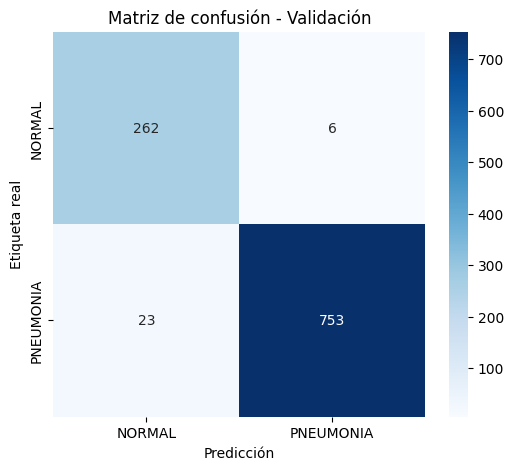

In [23]:
# ============================================================
# 15. VISUALIZACIÓN DE MATRIZ DE CONFUSIÓN
# ============================================================

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["NORMAL", "PNEUMONIA"],
    yticklabels=["NORMAL", "PNEUMONIA"]
)
plt.xlabel("Predicción")
plt.ylabel("Etiqueta real")
plt.title("Matriz de confusión - Validación")
plt.savefig(RESULTS_DIR / "matriz_confusion_validacion.png", dpi=300, bbox_inches="tight")
plt.show()

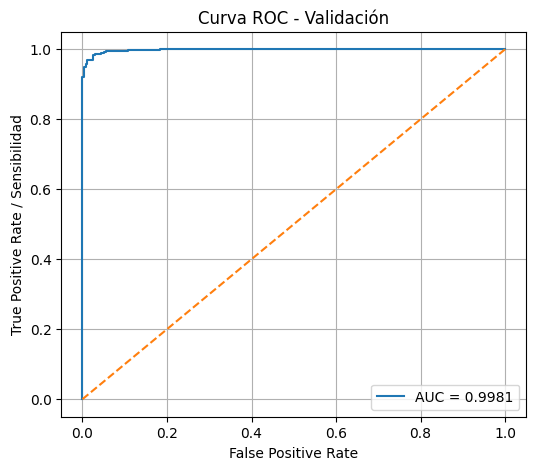

In [24]:
# ============================================================
# 16. CURVA ROC
# ============================================================

fpr, tpr, thresholds = roc_curve(y_true, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Sensibilidad")
plt.title("Curva ROC - Validación")
plt.legend()
plt.grid(True)
plt.savefig(RESULTS_DIR / "curva_roc_validacion.png", dpi=300, bbox_inches="tight")
plt.show()

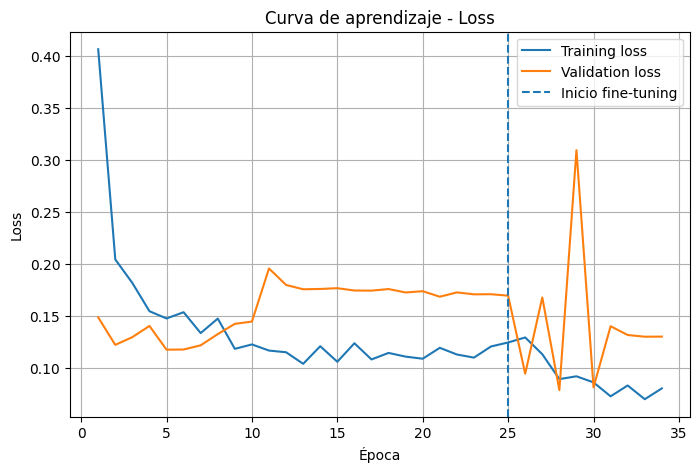

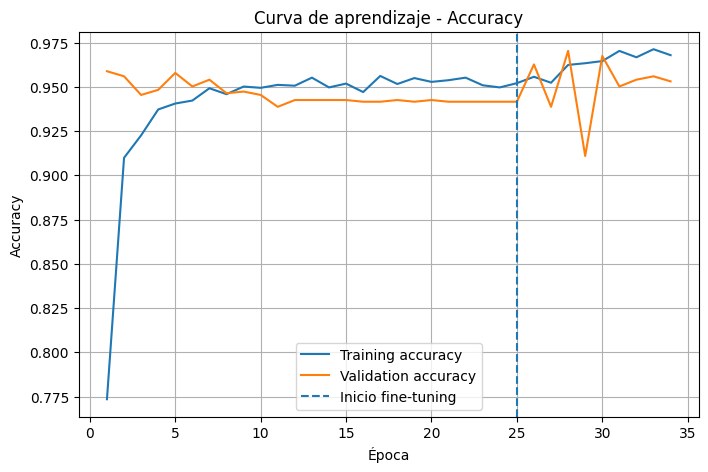

In [25]:
# ============================================================
# 17. CURVAS DE APRENDIZAJE: LOSS Y ACCURACY
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

# Unir historial de etapa congelada + fine-tuning
loss = history_frozen.history["loss"] + history_finetune.history["loss"]
val_loss = history_frozen.history["val_loss"] + history_finetune.history["val_loss"]

accuracy = history_frozen.history["accuracy"] + history_finetune.history["accuracy"]
val_accuracy = history_frozen.history["val_accuracy"] + history_finetune.history["val_accuracy"]

epochs = range(1, len(loss) + 1)

# ----------------------------
# Curva de Loss
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(epochs, loss, label="Training loss")
plt.plot(epochs, val_loss, label="Validation loss")
plt.axvline(x=len(history_frozen.history["loss"]), linestyle="--", label="Inicio fine-tuning")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.title("Curva de aprendizaje - Loss")
plt.legend()
plt.grid(True)
plt.savefig(RESULTS_DIR / "curva_loss.png", dpi=300, bbox_inches="tight")
plt.show()

# ----------------------------
# Curva de Accuracy
# ----------------------------
plt.figure(figsize=(8, 5))
plt.plot(epochs, accuracy, label="Training accuracy")
plt.plot(epochs, val_accuracy, label="Validation accuracy")
plt.axvline(x=len(history_frozen.history["accuracy"]), linestyle="--", label="Inicio fine-tuning")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.title("Curva de aprendizaje - Accuracy")
plt.legend()
plt.grid(True)
plt.savefig(RESULTS_DIR / "curva_accuracy.png", dpi=300, bbox_inches="tight")
plt.show()